# Building a QBTiles Archive from XYZ Tile Folders

This example demonstrates the full workflow:
1. Unzip a z/x/y tile folder
2. Build a QBTiles archive (.qbt index + .data) with v0.5.0 API
3. Load the index and retrieve a specific tile

## Sample tiles

Download the sample tile set (zoom 0-5, 1365 PNG tiles, 11MB):

```bash
curl -LO https://raw.githubusercontent.com/vuski/qbtiles/main/docs/examples/tiles.zip
```

## 1. Unzip sample tiles

In [1]:
import zipfile, os, sys

tiles_dir = "./tiles"
if not os.path.exists(tiles_dir):
    with zipfile.ZipFile("tiles.zip", "r") as zf:
        zf.extractall(tiles_dir)

# Quick check
n = sum(1 for r, d, fs in os.walk(tiles_dir) for f in fs if f.endswith(".png"))
print(f"{n} tiles extracted")

1365 tiles extracted


## 2. Build the archive

`index_tile_folder()` scans the z/x/y folder, `build_quadtree()` builds the tree, and `write_qbt_variable()` writes the .qbt index file. Tile data is concatenated separately.

In [2]:
sys.path.insert(0, os.path.join("..", "..", "src", "python"))
import qbtiles as qbt

qbt_path = "sample.qbt"
data_path = "sample.data"

# Scan tiles and build quadtree
entries = qbt.index_tile_folder(tiles_dir)
root = qbt.build_quadtree(entries)

# Write .qbt index (128B header + gzip-compressed bitmask + varints)
qbt.write_qbt_variable(qbt_path, root, zoom=5)

# Concatenate tile data in quadkey order
with open(data_path, "wb") as out:
    for qk, filepath, offset, length, run_length in entries:
        with open(filepath, "rb") as f:
            out.write(f.read())

idx_size = os.path.getsize(qbt_path)
data_size = os.path.getsize(data_path)
print(f"Tiles:  {len(entries):,}")
print(f"Index:  {idx_size:,} bytes ({idx_size/1024:.1f} KB)")
print(f"Data:   {data_size:,} bytes ({data_size/1024/1024:.1f} MB)")
print(f"Index overhead: {idx_size/data_size*100:.3f}%")

## 3. Retrieve a tile

Read the .qbt header, deserialize the index, then look up any tile by z/x/y.

In [3]:
import gzip

# Read .qbt file and parse header
header = qbt.read_qbt_header(qbt_path)
print(f"Format: QBT v{header["version"]}, zoom={header["zoom"]}")

# Decompress index section and deserialize
with open(qbt_path, "rb") as f:
    raw = f.read()
compressed = raw[header["header_size"]:header["header_size"] + header["bitmask_length"]]
index_bytes = gzip.decompress(compressed)
entries = qbt.deserialize_quadtree_index(index_bytes)
index = {e["quadkey_int"]: e for e in entries}
print(f"Loaded {len(index)} entries")

# Retrieve a tile by z/x/y
qk = qbt.tile_to_quadkey_int64(3, 4, 2)
entry = index[qk]
with open(data_path, "rb") as f:
    f.seek(entry["offset"])
    tile_data = f.read(entry["length"])
print(f"Tile z=3 x=4 y=2: {len(tile_data)} bytes")

# Verify against original
with open(os.path.join(tiles_dir, "3/4/2.png"), "rb") as f:
    assert tile_data == f.read(), "Mismatch!"
print("Matches original file.")

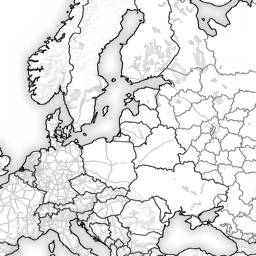

In [4]:
from IPython.display import display, Image
display(Image(data=tile_data))

In [5]:
# Cleanup
import shutil
for f in [qbt_path, data_path]:
    if os.path.exists(f): os.remove(f)
if os.path.exists(tiles_dir): shutil.rmtree(tiles_dir)
print("Cleaned up.")